In [2]:
import glob
parquets = sorted(glob.glob("/kaggle/input/**/*.parquet", recursive=True))
print("Found", len(parquets), "parquet files:")
for p in parquets:
    print(" -", p)

Found 3 parquet files:
 - /kaggle/input/datasets/shinyhoro/lr-and-sr-gluons-and-quarks/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet
 - /kaggle/input/datasets/shinyhoro/lr-and-sr-gluons-and-quarks/QCDToGGQQ_IMGjet_RH1all_jet0_run1_n47540_LR.parquet
 - /kaggle/input/datasets/shinyhoro/lr-and-sr-gluons-and-quarks/QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494_LR.parquet


In [3]:
import torch
import torch.nn as nn

class SimpleSRGenerator(nn.Module):
    # (B,3,64,64) -> (B,3,128,128)
    def __init__(self, in_ch=3, base=48, blocks=3):
        super().__init__()

        self.head = nn.Sequential(
            nn.Conv2d(in_ch, base, 3, 1, 1),
            nn.PReLU()
        )

        body = []
        for _ in range(blocks):
            body += [
                nn.Conv2d(base, base, 3, 1, 1),
                nn.PReLU(),
                nn.Conv2d(base, base, 3, 1, 1),
            ]

        self.body = nn.Sequential(*body)

        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(base, base, 3, 1, 1),
            nn.PReLU(),
            nn.Conv2d(base, 3, 3, 1, 1)
        )

    def forward(self, x):
        h = self.head(x)
        b = self.body(h) + h
        return self.up(b)

In [4]:
import os

os.listdir("/kaggle/input/datasets/shinyhoro/sr-baseline-generator/")

['sr_baseline_generator.pth']

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = SimpleSRGenerator().to(device)

weights = torch.load(
    "/kaggle/input/datasets/shinyhoro/sr-baseline-generator/sr_baseline_generator.pth",
    map_location=device
)

G.load_state_dict(weights)

G.train()

SimpleSRGenerator(
  (head): Sequential(
    (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): PReLU(num_parameters=1)
  )
  (body): Sequential(
    (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): PReLU(num_parameters=1)
    (2): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): PReLU(num_parameters=1)
    (5): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): PReLU(num_parameters=1)
    (8): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (up): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): PReLU(num_parameters=1)
    (3): Conv2d(48, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

In [6]:
print(next(G.parameters()).mean())

tensor(-0.0039, device='cuda:0', grad_fn=<MeanBackward0>)


In [7]:
x = torch.randn(1,3,64,64).to(device)

with torch.no_grad():
    y = G(x)

print(y.shape)

torch.Size([1, 3, 128, 128])


In [8]:
import torch
import glob
import hashlib
import numpy as np
import pyarrow.parquet as pq
from torch.utils.data import IterableDataset

PAD = (1,2,1,2)

def pad_hr_to_128(x):
    t,b,l,r = PAD
    return np.pad(x, ((0,0),(t,b),(l,r)), mode="constant", constant_values=0.0)

def normalize(x, cap=300.0):
    x = np.clip(x,0,cap)
    return np.log1p(x) / np.log1p(cap)


def split_of(file_path,row_id,seed=42):

    key = f"{seed}|{file_path}|{row_id}".encode("utf-8")
    h = hashlib.md5(key).hexdigest()

    bucket = int(h[:8],16) % 100

    if bucket < 80:
        return "train"
    elif bucket < 90:
        return "val"
    else:
        return "test"


class CMSMultiParquetSRIterable(IterableDataset):

    def __init__(self, parquet_paths, split,
                 cap=300.0,
                 batch_size=4,
                 seed=42,
                 max_samples=None):

        self.paths = list(parquet_paths)
        self.split = split
        self.cap = cap
        self.batch_size = batch_size
        self.seed = seed
        self.max_samples = max_samples


    def __iter__(self):

        cols = ["X_jets_LR","X_jets","pt","m0","y"]

        yielded = 0

        for path in self.paths:

            pf = pq.ParquetFile(path)
            row_id = 0

            for rb in pf.iter_batches(batch_size=self.batch_size,columns=cols):

                d = rb.to_pydict()
                n = len(d["y"])

                for i in range(n):

                    if split_of(path,row_id,self.seed) != self.split:
                        row_id += 1
                        continue

                    lr = np.array(d["X_jets_LR"][i],dtype=np.float32)
                    hr = np.array(d["X_jets"][i],dtype=np.float32)

                    lr = normalize(lr,self.cap)
                    hr = normalize(hr,self.cap)

                    hr128 = pad_hr_to_128(hr)

                    y  = int(d["y"][i])
                    pt = float(d["pt"][i])
                    m0 = float(d["m0"][i])

                    yield (
                        torch.from_numpy(lr).float(),
                        torch.from_numpy(hr128).float(),
                        torch.tensor(y),
                        torch.tensor(pt),
                        torch.tensor(m0)
                    )

                    yielded += 1
                    row_id += 1

                    if self.max_samples and yielded >= self.max_samples:
                        return

In [9]:
import torch
from torch.utils.data import DataLoader

parquets = glob.glob("/kaggle/input/datasets/shinyhoro/lr-and-sr-gluons-and-quarks/*.parquet")

print(parquets)

['/kaggle/input/datasets/shinyhoro/lr-and-sr-gluons-and-quarks/QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494_LR.parquet', '/kaggle/input/datasets/shinyhoro/lr-and-sr-gluons-and-quarks/QCDToGGQQ_IMGjet_RH1all_jet0_run1_n47540_LR.parquet', '/kaggle/input/datasets/shinyhoro/lr-and-sr-gluons-and-quarks/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet']


In [10]:
#Create Dataset Using All Files
train_ds = CMSMultiParquetSRIterable(
    parquets,
    split="train",
    cap=300.0,
    batch_size=2,
    max_samples=5000
)

In [12]:
#Create DataLoader
train_dl = DataLoader(
    train_ds,
    batch_size=8,
    num_workers=0,
    pin_memory=True
)

In [13]:
lr, hr128, y, pt, m0 = next(iter(train_dl))

print(lr.shape)
print(hr128.shape)

torch.Size([8, 3, 64, 64])
torch.Size([8, 3, 128, 128])


In [14]:
#Run the Baseline Model on Real Data
lr, hr128, y, pt, m0 = next(iter(train_dl))

lr = lr.to(device)
hr128 = hr128.to(device)

with torch.no_grad():
    sr = G(lr)

print("LR:", lr.shape)
print("SR:", sr.shape)
print("HR:", hr128.shape)

LR: torch.Size([8, 3, 64, 64])
SR: torch.Size([8, 3, 128, 128])
HR: torch.Size([8, 3, 128, 128])


In [15]:
#Energy Conservation Loss 

def energy_loss(pred, target):

    pred_energy = pred.sum(dim=(1,2,3))
    true_energy = target.sum(dim=(1,2,3))

    rel_error = (pred_energy - true_energy) / (true_energy + 1e-6)

    return torch.mean(rel_error**2)

In [16]:
#Centroid Loss

def centroid_loss(pred, target):

    B, C, H, W = pred.shape

    xs = torch.linspace(0,1,W, device=pred.device)
    ys = torch.linspace(0,1,H, device=pred.device)

    xs = xs.view(1,1,1,W)
    ys = ys.view(1,1,H,1)

    pred_energy = pred.sum(dim=(1,2,3), keepdim=True)
    true_energy = target.sum(dim=(1,2,3), keepdim=True)

    pred_x = (pred * xs).sum(dim=(1,2,3), keepdim=True) / (pred_energy + 1e-6)
    pred_y = (pred * ys).sum(dim=(1,2,3), keepdim=True) / (pred_energy + 1e-6)

    true_x = (target * xs).sum(dim=(1,2,3), keepdim=True) / (true_energy + 1e-6)
    true_y = (target * ys).sum(dim=(1,2,3), keepdim=True) / (true_energy + 1e-6)

    return torch.mean((pred_x - true_x)**2 + (pred_y - true_y)**2)

In [18]:
#Final PINN Loss
def pinn_loss(pred, target):

    pixel = torch.mean(torch.abs(pred - target))
    energy = energy_loss(pred, target)
    centroid = centroid_loss(pred, target)

    return pixel + 0.1*energy + 0.01*centroid

In [19]:
#Define Optimizer
optimizer = torch.optim.Adam(G.parameters(), lr=1e-5)

In [20]:
#PINN Training Loop

steps = 3000

for step in range(steps):

    lr, hr128, y, pt, m0 = next(iter(train_dl))

    lr = lr.to(device)
    hr128 = hr128.to(device)

    sr = G(lr)

    loss = pinn_loss(sr, hr128)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print(f"Step {step} | PINN loss: {loss.item()}")

Step 0 | PINN loss: 0.12587758898735046


KeyboardInterrupt: 

In [21]:
pixel = torch.mean(torch.abs(sr - hr128))
energy = energy_loss(sr, hr128)
centroid = centroid_loss(sr, hr128)

loss = pixel + 0.01*energy + 0.01*centroid

print("pixel:", pixel.item(), "energy:", energy.item(), "centroid:", centroid.item())

pixel: 0.001317380927503109 energy: 0.09741133451461792 centroid: 0.002302756067365408


In [22]:
torch.save(G.state_dict(), "/kaggle/working/pinn_sr_generator.pt")


In [23]:
#Build the GAN Discriminator

import torch.nn as nn

class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(3,64,3,1,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,64,3,2,1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,3,1,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,128,3,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,3,1,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),

            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

In [24]:
D = Discriminator().to(device)

In [26]:
#GAN Loss
bce = nn.BCELoss()
#Optimizers

opt_G = torch.optim.Adam(G.parameters(), lr=1e-5)
opt_D = torch.optim.Adam(D.parameters(), lr=1e-4)


In [27]:
#GAN Training Step

lr, hr128, y, pt, m0 = next(iter(train_dl))

lr = lr.to(device)
hr128 = hr128.to(device)

batch = lr.size(0)

real_labels = torch.ones(batch,1).to(device)
fake_labels = torch.zeros(batch,1).to(device)

In [28]:
#Train Discriminator

sr = G(lr).detach()

real_pred = D(hr128)
fake_pred = D(sr)

loss_real = bce(real_pred, real_labels)
loss_fake = bce(fake_pred, fake_labels)

d_loss = (loss_real + loss_fake) / 2

opt_D.zero_grad()
d_loss.backward()
opt_D.step()

In [29]:
#Train Generator

sr = G(lr)

fake_pred = D(sr)

adv_loss = bce(fake_pred, real_labels)

pixel = torch.mean(torch.abs(sr - hr128))

g_loss = pixel + 1e-3 * adv_loss

opt_G.zero_grad()
g_loss.backward()
opt_G.step()

In [30]:
D = Discriminator().to(device)
print(D)

Discriminator(
  (net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2)
    (11): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): LeakyReLU(negative_slope=0.2)
    (14): AdaptiveAvgPool2d

In [31]:
#Training Loop

steps = 30000

for step in range(steps):

    lr, hr128, y, pt, m0 = next(iter(train_dl))

    lr = lr.to(device)
    hr128 = hr128.to(device)

    batch = lr.size(0)

    real_labels = torch.ones(batch,1).to(device)
    fake_labels = torch.zeros(batch,1).to(device)

    # ---- Train D ----
    sr = G(lr).detach()

    real_pred = D(hr128)
    fake_pred = D(sr)

    d_loss = (bce(real_pred,real_labels) + bce(fake_pred,fake_labels))/2

    opt_D.zero_grad()
    d_loss.backward()
    opt_D.step()

    # ---- Train G ----
    sr = G(lr)

    fake_pred = D(sr)

    adv_loss = bce(fake_pred,real_labels)

    pixel = torch.mean(torch.abs(sr - hr128))

    g_loss = pixel + 1e-3 * adv_loss

    opt_G.zero_grad()
    g_loss.backward()
    opt_G.step()

    if step % 50 == 0:
        print(f"step {step} | D: {d_loss.item()} | G: {g_loss.item()}")

step 0 | D: 0.685865581035614 | G: 0.0016572747845202684


KeyboardInterrupt: 

In [34]:
torch.save(G.state_dict(), "/kaggle/working/final_sr_pinn_gan.pt")

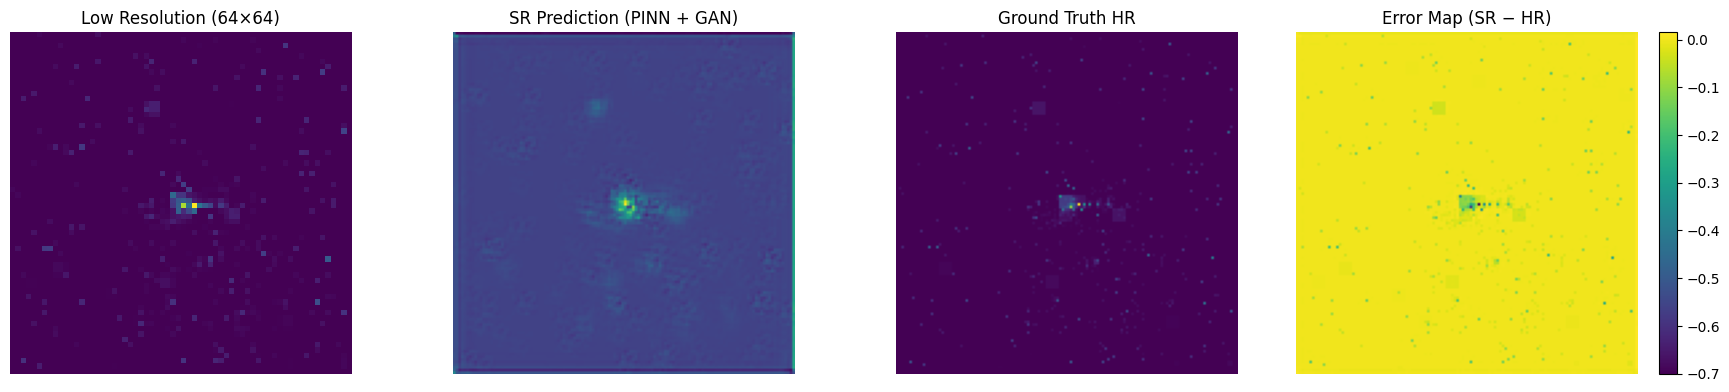

In [40]:
import matplotlib.pyplot as plt
import torch

import os

os.makedirs("/kaggle/working/results", exist_ok=True)


# get one batch
lr, hr128, y, pt, m0 = next(iter(train_dl))

lr = lr.to(device)
hr128 = hr128.to(device)

# generate SR prediction
with torch.no_grad():
    sr = G(lr)

# move to CPU and convert to numpy
lr = lr[0].cpu().numpy()
sr = sr[0].cpu().numpy()
hr = hr128[0].cpu().numpy()

# combine 3 channels → total energy map
lr_map = lr.sum(axis=0)
sr_map = sr.sum(axis=0)
hr_map = hr.sum(axis=0)

# compute error
error_map = sr_map - hr_map

# plot
fig, ax = plt.subplots(1,4, figsize=(18,4))

ax[0].imshow(lr_map)
ax[0].set_title("Low Resolution (64×64)")
ax[0].axis("off")

ax[1].imshow(sr_map)
ax[1].set_title("SR Prediction (PINN + GAN)")
ax[1].axis("off")

ax[2].imshow(hr_map)
ax[2].set_title("Ground Truth HR")
ax[2].axis("off")

im = ax[3].imshow(error_map)
ax[3].set_title("Error Map (SR − HR)")
ax[3].axis("off")

fig.colorbar(im, ax=ax[3])

plt.tight_layout()

# save for report
plt.savefig("/kaggle/working/results/pinn_output.png", dpi=300)

plt.show()